# M4 — Fine-tuning CheXpert | Center Crop | Política Híbrida U-Ignore + U-Ones
**Projeto Integrador SENAI FATESG 2025/2026**  
Política diferenciada por label: U-Ignore (atelectasis, cardiomegaly, consolidation, edema) + U-Ones seletivo (pleural_effusion, pneumothorax) | Base: m2_crop_final.keras

## SEÇÃO 0 — Setup e Instalações

In [1]:
!pip install -q tensorflow keras scikit-learn matplotlib pandas numpy

In [2]:
import os, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers

from google.colab import drive
drive.mount('/content/drive')

gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs: {gpus}')
print(f'TensorFlow: {tf.__version__}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

Mounted at /content/drive
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow: 2.20.0


In [3]:
# ── Caminhos ──────────────────────────────────────────────────────────────────
BASE_DRIVE  = '/content/drive/MyDrive'
CHEX_DIR    = f'{BASE_DRIVE}/datasets_pi_2026/estruturacao/Stanford_Cropping'
TRAIN_CSV   = f'{CHEX_DIR}/chex_crop_train.csv'
VALID_CSV   = f'{CHEX_DIR}/chex_crop_valid.csv'

# Ponto de partida: M2 Crop (melhor modelo validado)
M2_CKPT     = f'{BASE_DRIVE}/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/m2_crop_final.keras'

OUT_DIR     = f'{BASE_DRIVE}/datasets_pi_2026/modelos/M4_CheXpert_Crop_Hybrid'
CKPT_DIR    = f'{OUT_DIR}/checkpoints'
LOG_DIR     = f'{OUT_DIR}/logs'
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(LOG_DIR,  exist_ok=True)

# ── Labels e política híbrida ─────────────────────────────────────────────────
LABELS   = ['atelectasis','cardiomegaly','pleural_effusion',
            'pneumothorax','consolidation','edema']
N_LABELS = len(LABELS)

# Índices da política por label
# U-Ignore: -1 descartados da loss (igual ao M2)
# U-Ones  : -1 convertidos para soft positive (novo no M4)
UONES_LABELS   = ['pleural_effusion', 'pneumothorax']
UIGNORE_LABELS = ['atelectasis', 'cardiomegaly', 'consolidation', 'edema']
UONES_IDX   = [LABELS.index(l) for l in UONES_LABELS]    # [2, 3]
UIGNORE_IDX = [LABELS.index(l) for l in UIGNORE_LABELS]  # [0, 1, 4, 5]

# ── Hiperparâmetros ───────────────────────────────────────────────────────────
IMG_SIZE   = 512
BATCH_SIZE = 32
EPOCHS_P1  = 15
EPOCHS_P2  = 40
EPOCHS_P3  = 30
LR_P1      = 1e-3
LR_P2      = 1e-4
LR_P3      = 1e-5
PATIENCE   = 7
PREFIX     = 'm4_crop'

# ── Label Smoothing — apenas para labels U-Ones ───────────────────────────────
# epsilon=0.15: targets 1→0.85, 0→0.15 (soft positive conservador)
# epsilon=0.20: targets 1→0.80, 0→0.20 (soft positive mais agressivo)
LABEL_SMOOTHING_EPSILON = 0.15   # ← altere aqui: 0.15 ou 0.20

print(f'M2 ckpt   : {M2_CKPT}')
print(f'Out dir   : {OUT_DIR}')
print(f'Epochs    : P1={EPOCHS_P1} | P2={EPOCHS_P2} | P3={EPOCHS_P3} | Total={EPOCHS_P1+EPOCHS_P2+EPOCHS_P3}')
print(f'LS epsilon: {LABEL_SMOOTHING_EPSILON} (aplicado APENAS em {UONES_LABELS})')
print(f'U-Ones    : {UONES_LABELS} (idx {UONES_IDX})')
print(f'U-Ignore  : {UIGNORE_LABELS} (idx {UIGNORE_IDX})')
print(f'Existe M2 : {"✅" if os.path.exists(M2_CKPT) else "❌ NÃO ENCONTRADO"}')

M2 ckpt   : /content/drive/MyDrive/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/m2_crop_final.keras
Out dir   : /content/drive/MyDrive/datasets_pi_2026/modelos/M4_CheXpert_Crop_Hybrid
Epochs    : P1=15 | P2=40 | P3=30 | Total=85
LS epsilon: 0.15 (aplicado APENAS em ['pleural_effusion', 'pneumothorax'])
U-Ones    : ['pleural_effusion', 'pneumothorax'] (idx [2, 3])
U-Ignore  : ['atelectasis', 'cardiomegaly', 'consolidation', 'edema'] (idx [0, 1, 4, 5])
Existe M2 : ✅


## SEÇÃO 1 — Carregamento e Validação dos CSVs

In [7]:
df_train = pd.read_csv(TRAIN_CSV)
df_valid = pd.read_csv(VALID_CSV)

print(f'Train: {len(df_train):,} | Valid: {len(df_valid):,}')

# Valida paths
sample = df_train['img_path'].sample(5, random_state=42).tolist()
print('\nValidação de paths:')
for p in sample:
    print(f'  {"✅" if os.path.exists(p) else "❌"} {p.split("/")[-1]}')

print('\nDistribuição train — Política Híbrida:')
print(f'  {"Label":<20} {"Política":>10} {"Confirmados":>13} {"Incertos":>10} {"Negativos":>10} {"Efetivos loss":>15}')
print('  ' + '-'*80)
for lbl in LABELS:
    col_m2 = f'{lbl}_uignore'
    col_m3 = f'{lbl}_uones'
    # Usa coluna disponível no CSV
    col = col_m3 if col_m3 in df_train.columns else col_m2
    n_conf = (df_train[col] == 1).sum()
    n_nan  = df_train[col].isna().sum()
    n_neg  = (df_train[col] == 0).sum()
    politica = 'U-Ones' if lbl in UONES_LABELS else 'U-Ignore'
    efetivos = n_conf + n_nan if lbl in UONES_LABELS else n_conf
    print(f'  {lbl:<20} {politica:>10} {n_conf:>13,} {n_nan:>10,} {n_neg:>10,} {efetivos:>15,}')

Train: 87,258 | Valid: 159

Validação de paths:
  ✅ CheXpert-v1.0_train_patient15426_study40_view1_frontal.png
  ✅ CheXpert-v1.0_train_patient06871_study2_view1_frontal.png
  ✅ CheXpert-v1.0_train_patient32844_study1_view1_frontal.png
  ✅ CheXpert-v1.0_train_patient10968_study5_view1_frontal.png
  ✅ CheXpert-v1.0_train_patient31405_study1_view1_frontal.png

Distribuição train — Política Híbrida:
  Label                  Política   Confirmados   Incertos  Negativos   Efetivos loss
  --------------------------------------------------------------------------------
  atelectasis            U-Ignore        29,173     57,585        500          29,173
  cardiomegaly           U-Ignore        19,457     64,598      3,203          19,457
  pleural_effusion         U-Ones        40,459     35,722     11,077          76,181
  pneumothorax             U-Ones        16,023     51,845     19,390          67,868
  consolidation          U-Ignore        19,919     59,180      8,159          19,919
  

## SEÇÃO 2 — Dataset Pipeline Híbrido

In [8]:
# ── Constrói label array + máscara híbrida ────────────────────────────────────
# Shape: (N, N_LABELS*2) = (N, 12)
# Primeiros 6: label values | Últimos 6: máscara de validade
#
# U-Ignore labels: NaN → label=0, mask=0 (exclui da loss)
# U-Ones labels  : NaN → label=1, mask=1 (entra como soft positive)

def get_label_cols(df):
    """Retorna as colunas corretas (uones ou uignore) de acordo com disponibilidade."""
    cols = []
    for lbl in LABELS:
        col_uones   = f'{lbl}_uones'
        col_uignore = f'{lbl}_uignore'
        if col_uones in df.columns:
            cols.append(col_uones)
        elif col_uignore in df.columns:
            cols.append(col_uignore)
        else:
            raise ValueError(f'Coluna não encontrada para {lbl}')
    return cols

LABEL_COLS = get_label_cols(df_train)
print(f'Colunas utilizadas: {LABEL_COLS}')

def build_hybrid_labels(df, label_cols):
    """
    Aplica política híbrida por label.
    Retorna: label_mask array shape (N, N_LABELS*2)
    """
    label_arr = df[label_cols].values.copy().astype(np.float32)
    mask_arr  = np.ones_like(label_arr)

    # U-Ignore: NaN → label=0, mask=0
    for idx in UIGNORE_IDX:
        nan_pos = np.isnan(label_arr[:, idx])
        label_arr[nan_pos, idx] = 0.0
        mask_arr[nan_pos, idx]  = 0.0

    # U-Ones: NaN → label=1, mask=1 (já é 1)
    for idx in UONES_IDX:
        nan_pos = np.isnan(label_arr[:, idx])
        label_arr[nan_pos, idx] = 1.0
        # mask permanece 1

    return np.concatenate([label_arr, mask_arr], axis=1).astype(np.float32)

def load_image_chex(img_path, label_mask, training=False):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.cast(img, tf.float32) / 255.0
    img = (img - 0.5056) / 0.2520
    img = tf.repeat(img, 3, axis=-1)
    img = tf.ensure_shape(img, [IMG_SIZE, IMG_SIZE, 3])
    if training:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.1)
        img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    return img, label_mask

def make_dataset_hybrid(df, label_cols, training=False, batch_size=BATCH_SIZE):
    paths      = df['img_path'].values
    label_mask = build_hybrid_labels(df, label_cols)

    ds = tf.data.Dataset.from_tensor_slices((paths, label_mask))
    ds = ds.map(lambda p, lm: load_image_chex(p, lm, training=training),
                num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=4096, seed=SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

print('Criando datasets...')
ds_train = make_dataset_hybrid(df_train, LABEL_COLS, training=True)
ds_valid = make_dataset_hybrid(df_valid, LABEL_COLS, training=False)
print(f'Train batches: {len(ds_train):,} | Valid batches: {len(ds_valid):,}')

for imgs, lm in ds_train.take(1):
    labels = lm[:, :N_LABELS]; mask = lm[:, N_LABELS:]
    print(f'Batch shape      : {imgs.shape}')
    print(f'Label+mask shape : {lm.shape}')
    print(f'Label sample[0]  : {labels[0].numpy()}')
    print(f'Mask  sample[0]  : {mask[0].numpy()}')
    valid_frac = mask.numpy().mean()
    print(f'Mask coverage    : {valid_frac:.3f} (fração de labels válidos/ativos por batch)')
    break

Colunas utilizadas: ['atelectasis_uones', 'cardiomegaly_uones', 'pleural_effusion_uones', 'pneumothorax_uones', 'consolidation_uones', 'edema_uones']
Criando datasets...
Train batches: 2,727 | Valid batches: 5
Batch shape      : (32, 512, 512, 3)
Label+mask shape : (32, 12)
Label sample[0]  : [0. 0. 1. 1. 0. 0.]
Mask  sample[0]  : [0. 0. 1. 1. 1. 0.]
Mask coverage    : 0.552 (fração de labels válidos/ativos por batch)


## SEÇÃO 3 — Focal Loss Híbrida e MacroAUROC

In [9]:
class FocalLossHybrid(tf.keras.losses.Loss):
    """
    Focal Loss com política híbrida U-Ignore + U-Ones com Label Smoothing.

    Recebe y_true shape (batch, N_LABELS*2):
      - y_true[:, :N_LABELS] = labels (0/1, com 1 para U-Ones convertidos)
      - y_true[:, N_LABELS:] = máscara (0=U-Ignore incerto, 1=participante)

    Label Smoothing aplicado APENAS nas posições U-Ones (UONES_IDX).
    U-Ignore incertos têm mask=0, contribuição zerada na loss.
    """
    def __init__(self, gamma=2.0, alpha=0.25, epsilon=0.15,
                 uones_idx=None, label_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma    = gamma
        self.alpha    = alpha
        self.epsilon  = epsilon
        self.uones_idx = uones_idx or []
        self.label_weights = (tf.constant(label_weights, dtype=tf.float32)
                              if label_weights is not None
                              else tf.ones(N_LABELS, dtype=tf.float32))

        # Máscara de smoothing: epsilon nas posições U-Ones, 0 nas demais
        smooth_mask = np.zeros(N_LABELS, dtype=np.float32)
        for idx in self.uones_idx:
            smooth_mask[idx] = 1.0
        self.smooth_mask = tf.constant(smooth_mask)   # shape (N_LABELS,)

    def call(self, y_true, y_pred):
        labels = y_true[:, :N_LABELS]
        mask   = y_true[:, N_LABELS:]

        # Label Smoothing diferenciado: só nas posições U-Ones
        eps_per_label = self.epsilon * self.smooth_mask          # (N_LABELS,)
        y_smooth = labels * (1.0 - eps_per_label) + (1.0 - labels) * eps_per_label

        y_pred  = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce     = -(y_smooth * tf.math.log(y_pred) +
                    (1.0 - y_smooth) * tf.math.log(1.0 - y_pred))
        p_t     = labels * y_pred + (1 - labels) * (1 - y_pred)
        alpha_t = labels * self.alpha + (1 - labels) * (1 - self.alpha)
        focal   = alpha_t * tf.pow(1 - p_t, self.gamma) * bce * self.label_weights

        # Aplica máscara: U-Ignore incertos → contribuição zero
        focal_masked = focal * mask
        n_valid = tf.reduce_sum(mask) + 1e-7
        return tf.reduce_sum(focal_masked) / n_valid

    def get_config(self):
        config = super().get_config()
        config.update({'gamma': self.gamma, 'alpha': self.alpha,
                       'epsilon': self.epsilon, 'uones_idx': self.uones_idx,
                       'label_weights': self.label_weights.numpy().tolist()})
        return config


class MacroAUROC(tf.keras.metrics.Metric):
    """Macro-AUROC — extrai primeiros N_LABELS do y_true concatenado."""
    def __init__(self, n_labels=N_LABELS, name='macro_auroc', **kwargs):
        super().__init__(name=name, **kwargs)
        self.n_labels = n_labels
        self.aucs = [tf.keras.metrics.AUC(curve='ROC', name=f'auc_{i}')
                     for i in range(n_labels)]
    def update_state(self, y_true, y_pred, sample_weight=None):
        labels = y_true[:, :self.n_labels]
        for i, auc in enumerate(self.aucs):
            auc.update_state(labels[:, i], y_pred[:, i], sample_weight)
    def result(self):
        return tf.reduce_mean([auc.result() for auc in self.aucs])
    def reset_state(self):
        for auc in self.aucs: auc.reset_state()
    def get_config(self):
        c = super().get_config(); c['n_labels'] = self.n_labels; return c


class MaskedBinaryAccuracy(tf.keras.metrics.Metric):
    """BinaryAccuracy sobre primeiros N_LABELS (ignora parte máscara)."""
    def __init__(self, n_labels=N_LABELS, name='accuracy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.n_labels = n_labels
        self.acc = tf.keras.metrics.BinaryAccuracy()
    def update_state(self, y_true, y_pred, sample_weight=None):
        self.acc.update_state(y_true[:, :self.n_labels], y_pred)
    def result(self): return self.acc.result()
    def reset_state(self): self.acc.reset_state()
    def get_config(self):
        c = super().get_config(); c['n_labels'] = self.n_labels; return c


# ── Label weights híbridos ────────────────────────────────────────────────────
# U-Ignore: pesos sobre confirmados apenas (como M2)
# U-Ones  : pesos sobre positivos efetivos (confirmados + convertidos, como M3)
N = len(df_train)
label_weights_focal = []
for i, lbl in enumerate(LABELS):
    col = LABEL_COLS[i]
    n_conf = (df_train[col] == 1).sum()
    n_nan  = df_train[col].isna().sum()
    if lbl in UONES_LABELS:
        n_eff = n_conf + n_nan   # efetivos U-Ones
    else:
        n_eff = n_conf           # só confirmados U-Ignore
    w = N / (N_LABELS * n_eff) if n_eff > 0 else 1.0
    label_weights_focal.append(float(w))
label_weights_focal = np.array(label_weights_focal, dtype=np.float32)

print(f'Label weights híbridos (ε={LABEL_SMOOTHING_EPSILON} em {UONES_LABELS}):')
print(f'  {"Label":<20} {"Política":>10} {"Efetivos":>10} {"Peso":>8}')
print('  ' + '-'*52)
for lbl, w in zip(LABELS, label_weights_focal):
    col = LABEL_COLS[LABELS.index(lbl)]
    n_conf = (df_train[col] == 1).sum()
    n_nan  = df_train[col].isna().sum()
    n_eff  = n_conf + n_nan if lbl in UONES_LABELS else n_conf
    pol    = 'U-Ones' if lbl in UONES_LABELS else 'U-Ignore'
    print(f'  {lbl:<20} {pol:>10} {n_eff:>10,} {w:>8.4f}')

CUSTOM_OBJECTS = {
    'FocalLossHybrid'     : FocalLossHybrid,
    'MacroAUROC'          : MacroAUROC,
    'MaskedBinaryAccuracy': MaskedBinaryAccuracy,
}

Label weights híbridos (ε=0.15 em ['pleural_effusion', 'pneumothorax']):
  Label                  Política   Efetivos     Peso
  ----------------------------------------------------
  atelectasis            U-Ignore     29,173   0.4985
  cardiomegaly           U-Ignore     19,457   0.7474
  pleural_effusion         U-Ones     76,181   0.1909
  pneumothorax             U-Ones     67,868   0.2143
  consolidation          U-Ignore     19,919   0.7301
  edema                  U-Ignore     30,177   0.4819


## SEÇÃO 4 — Carrega Backbone M2 e Verifica Arquitetura

In [10]:
print(f'Carregando M2: {M2_CKPT}')
if not os.path.exists(M2_CKPT):
    raise FileNotFoundError(f'M2 não encontrado: {M2_CKPT}')

try:
    model_test = tf.keras.models.load_model(M2_CKPT, compile=False)
except Exception:
    from tensorflow.keras import losses, metrics as km
    m2_custom = {
        'FocalLossUIgnore'    : type('FocalLossUIgnore', (losses.Loss,), {}),
        'MacroAUROC'          : type('MacroAUROC', (km.Metric,), {}),
        'MaskedBinaryAccuracy': type('MaskedBinaryAccuracy', (km.Metric,), {}),
    }
    model_test = tf.keras.models.load_model(M2_CKPT, compile=False,
                                            custom_objects=m2_custom)

total     = model_test.count_params()
print(f'Total parâmetros : {total:,}')
print(f'Camadas          : {len(model_test.layers)}')
print(f'Input shape      : {model_test.input_shape}')
print(f'Output shape     : {model_test.output_shape}')
del model_test
print('\n M2 carregável e compatível com M4')

Carregando M2: /content/drive/MyDrive/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/m2_crop_final.keras
Total parâmetros : 22,045,486
Camadas          : 139
Input shape      : (None, 512, 512, 3)
Output shape     : (None, 6)

 M2 carregável e compatível com M4


## SEÇÃO 5 — Callbacks e Funções de Retomada

In [11]:
def get_callbacks(phase, model_name):
    ckpt_path = f'{CKPT_DIR}/{model_name}_best.keras'
    cb_list = [
        callbacks.ModelCheckpoint(
            filepath=ckpt_path,
            monitor='val_macro_auroc', mode='max',
            save_best_only=True, verbose=1
        ),
        callbacks.EarlyStopping(
            monitor='val_macro_auroc', mode='max',
            patience=PATIENCE, restore_best_weights=True, verbose=1
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_macro_auroc', mode='max',
            factor=0.5, patience=3, min_lr=1e-7, verbose=1
        ),
        callbacks.CSVLogger(
            f'{LOG_DIR}/{PREFIX}_fase{phase}_history.csv', append=True
        ),
        callbacks.TensorBoard(
            log_dir=f'{LOG_DIR}/fase{phase}', histogram_freq=0
        ),
    ]
    return cb_list, ckpt_path


def load_checkpoint(ckpt_path):
    if os.path.exists(ckpt_path):
        print(f'Checkpoint encontrado: {ckpt_path}')
        model = tf.keras.models.load_model(ckpt_path, custom_objects=CUSTOM_OBJECTS)
        return model, True
    print(f'Sem checkpoint — iniciando do zero: {ckpt_path}')
    return None, False


def load_m2_as_base():
    """Carrega M2 tratando classes customizadas desconhecidas."""
    try:
        model = tf.keras.models.load_model(M2_CKPT, compile=False)
    except Exception:
        from tensorflow.keras import losses, metrics as km
        m2_custom = {
            'FocalLossUIgnore'    : type('FocalLossUIgnore', (losses.Loss,), {}),
            'MacroAUROC'          : type('MacroAUROC', (km.Metric,), {}),
            'MaskedBinaryAccuracy': type('MaskedBinaryAccuracy', (km.Metric,), {}),
        }
        model = tf.keras.models.load_model(M2_CKPT, compile=False,
                                           custom_objects=m2_custom)
    return model


def get_initial_epoch(phase):
    log_path = f'{LOG_DIR}/{PREFIX}_fase{phase}_history.csv'
    if os.path.exists(log_path):
        try:
            df_log = pd.read_csv(log_path)
            epochs_done = len(df_log)
            print(f'  → {epochs_done} epochs já concluídos nesta fase')
            return epochs_done
        except Exception:
            return 0
    return 0


def compile_model(model, lr):
    """Compila com FocalLossHybrid e métricas."""
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss=FocalLossHybrid(
            gamma=2.0, alpha=0.25,
            epsilon=LABEL_SMOOTHING_EPSILON,
            uones_idx=UONES_IDX,
            label_weights=label_weights_focal
        ),
        metrics=[MacroAUROC(name='macro_auroc'),
                 MaskedBinaryAccuracy(name='accuracy')]
    )
    return model


print('Callbacks e funções definidos.')
print(f'ε={LABEL_SMOOTHING_EPSILON} aplicado em: {UONES_LABELS}')

Callbacks e funções definidos.
ε=0.15 aplicado em: ['pleural_effusion', 'pneumothorax']


## SEÇÃO 6 — Fase 1: Frozen Backbone

In [12]:
print('='*60)
print(f'FASE 1 — Frozen backbone | LR={LR_P1} | Epochs={EPOCHS_P1}')
print(f'         Política Híbrida | ε={LABEL_SMOOTHING_EPSILON} em {UONES_LABELS}')
print('='*60)

CKPT_P1 = f'{CKPT_DIR}/{PREFIX}_fase1_best.keras'
cb_p1, _ = get_callbacks(phase=1, model_name=f'{PREFIX}_fase1')
initial_epoch_p1 = get_initial_epoch(phase=1)

model_p1, loaded = load_checkpoint(CKPT_P1)
if not loaded:
    model_p1 = load_m2_as_base()
    for layer in model_p1.layers:
        layer.trainable = False
    head_layers = ['global_average_pooling2d', 'dense',
                   'batch_normalization', 'dropout', 'predictions']
    for layer in model_p1.layers:
        for name in head_layers:
            if name in layer.name:
                layer.trainable = True
                break

compile_model(model_p1, LR_P1)

trainable_p1 = sum([tf.size(w).numpy() for w in model_p1.trainable_weights])
print(f'Treináveis Fase 1: {trainable_p1:,}')
print(f'Iniciando do epoch: {initial_epoch_p1 + 1}')

if initial_epoch_p1 >= EPOCHS_P1:
    print('Fase 1 já concluída — pulando para Fase 2.')
else:
    history_p1 = model_p1.fit(
        ds_train,
        validation_data=ds_valid,
        epochs=EPOCHS_P1,
        initial_epoch=initial_epoch_p1,
        callbacks=cb_p1,
        verbose=1
    )
    print(f'\n Fase 1 concluída. Melhor val_macro_auroc: {max(history_p1.history["val_macro_auroc"]):.4f}')

FASE 1 — Frozen backbone | LR=0.001 | Epochs=15
         Política Híbrida | ε=0.15 em ['pleural_effusion', 'pneumothorax']
Sem checkpoint — iniciando do zero: /content/drive/MyDrive/datasets_pi_2026/modelos/M4_CheXpert_Crop_Hybrid/checkpoints/m4_crop_fase1_best.keras
Treináveis Fase 1: 1,187,254
Iniciando do epoch: 1
Epoch 1/15
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6068 - loss: 0.0117 - macro_auroc: 0.7497
Epoch 1: val_macro_auroc improved from None to 0.85751, saving model to /content/drive/MyDrive/datasets_pi_2026/modelos/M4_CheXpert_Crop_Hybrid/checkpoints/m4_crop_fase1_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/datasets_pi_2026/modelos/M4_CheXpert_Crop_Hybrid/checkpoints/m4_crop_fase1_best.keras
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 5978s 2s/step - accuracy: 0.6084 - loss: 0.0115 - macro_auroc: 0.7465 - val_accuracy: 0.6111 - val_loss: 0.0879 - val_macro_auroc: 0.8575 - learning_rate: 0.0010
Epoch 2/15
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/ste

## SEÇÃO 7 — Fase 2: Unfreeze Top 30%

In [13]:
print('='*60)
print(f'FASE 2 — Unfreeze top 30% | LR={LR_P2} | Epochs={EPOCHS_P2}')
print('='*60)

CKPT_P2 = f'{CKPT_DIR}/{PREFIX}_fase2_best.keras'
cb_p2, _ = get_callbacks(phase=2, model_name=f'{PREFIX}_fase2')
initial_epoch_p2 = get_initial_epoch(phase=2)

model_p2, loaded = load_checkpoint(CKPT_P2)
if not loaded:
    model_p2, loaded_p1 = load_checkpoint(CKPT_P1)
    if not loaded_p1:
        raise RuntimeError('Checkpoint Fase 1 não encontrado.')
    all_layers    = model_p2.layers
    n_total       = len(all_layers)
    n_unfreeze    = int(n_total * 0.30)
    unfreeze_from = n_total - n_unfreeze
    print(f'Total camadas: {n_total} | Descongelando últimas {n_unfreeze} (idx {unfreeze_from}+)')
    for i, layer in enumerate(all_layers):
        layer.trainable = (i >= unfreeze_from)
    for layer in all_layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
else:
    all_layers    = model_p2.layers
    n_total       = len(all_layers)
    n_unfreeze    = int(n_total * 0.30)
    unfreeze_from = n_total - n_unfreeze
    for i, layer in enumerate(all_layers):
        layer.trainable = (i >= unfreeze_from)
    for layer in all_layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

compile_model(model_p2, LR_P2)

trainable_p2 = sum([tf.size(w).numpy() for w in model_p2.trainable_weights])
print(f'Treináveis Fase 2: {trainable_p2:,}')
print(f'Iniciando do epoch: {initial_epoch_p2 + 1}')

if initial_epoch_p2 >= EPOCHS_P2:
    print('Fase 2 já concluída — pulando para Fase 3.')
else:
    history_p2 = model_p2.fit(
        ds_train,
        validation_data=ds_valid,
        epochs=EPOCHS_P2,
        initial_epoch=initial_epoch_p2,
        callbacks=cb_p2,
        verbose=1
    )
    print(f'\n Fase 2 concluída. Melhor val_macro_auroc: {max(history_p2.history["val_macro_auroc"]):.4f}')

FASE 2 — Unfreeze top 30% | LR=0.0001 | Epochs=40
Sem checkpoint — iniciando do zero: /content/drive/MyDrive/datasets_pi_2026/modelos/M4_CheXpert_Crop_Hybrid/checkpoints/m4_crop_fase2_best.keras
Checkpoint encontrado: /content/drive/MyDrive/datasets_pi_2026/modelos/M4_CheXpert_Crop_Hybrid/checkpoints/m4_crop_fase1_best.keras
Total camadas: 139 | Descongelando últimas 41 (idx 98+)
Treináveis Fase 2: 10,640,302
Iniciando do epoch: 1
Epoch 1/40
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - accuracy: 0.6203 - loss: 0.0113 - macro_auroc: 0.7506
Epoch 1: val_macro_auroc improved from None to 0.82643, saving model to /content/drive/MyDrive/datasets_pi_2026/modelos/M4_CheXpert_Crop_Hybrid/checkpoints/m4_crop_fase2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/datasets_pi_2026/modelos/M4_CheXpert_Crop_Hybrid/checkpoints/m4_crop_fase2_best.keras
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 885s 314ms/step - accuracy: 0.6148 - loss: 0.0113 - macro_auroc: 0.7438 - val_accuracy: 0.6834 - 

## SEÇÃO 8 — Fase 3: Unfreeze Completo

In [14]:
print('='*60)
print(f'FASE 3 — Unfreeze completo | LR={LR_P3} | Epochs={EPOCHS_P3}')
print('='*60)

CKPT_P3 = f'{CKPT_DIR}/{PREFIX}_fase3_best.keras'
cb_p3, _ = get_callbacks(phase=3, model_name=f'{PREFIX}_fase3')
initial_epoch_p3 = get_initial_epoch(phase=3)

model_p3, loaded = load_checkpoint(CKPT_P3)
if not loaded:
    model_p3, loaded_p2 = load_checkpoint(CKPT_P2)
    if not loaded_p2:
        raise RuntimeError('Checkpoint Fase 2 não encontrado.')
    for layer in model_p3.layers:
        layer.trainable = True
    for layer in model_p3.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False
else:
    for layer in model_p3.layers:
        layer.trainable = True
    for layer in model_p3.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

compile_model(model_p3, LR_P3)

trainable_p3 = sum([tf.size(w).numpy() for w in model_p3.trainable_weights])
print(f'Treináveis Fase 3: {trainable_p3:,}')
print(f'Iniciando do epoch: {initial_epoch_p3 + 1}')

if initial_epoch_p3 >= EPOCHS_P3:
    print('Fase 3 já concluída — indo para avaliação final.')
else:
    history_p3 = model_p3.fit(
        ds_train,
        validation_data=ds_valid,
        epochs=EPOCHS_P3,
        initial_epoch=initial_epoch_p3,
        callbacks=cb_p3,
        verbose=1
    )
    print(f'\n Fase 3 concluída. Melhor val_macro_auroc: {max(history_p3.history["val_macro_auroc"]):.4f}')

FASE 3 — Unfreeze completo | LR=1e-05 | Epochs=30
Sem checkpoint — iniciando do zero: /content/drive/MyDrive/datasets_pi_2026/modelos/M4_CheXpert_Crop_Hybrid/checkpoints/m4_crop_fase3_best.keras
Checkpoint encontrado: /content/drive/MyDrive/datasets_pi_2026/modelos/M4_CheXpert_Crop_Hybrid/checkpoints/m4_crop_fase2_best.keras
Treináveis Fase 3: 21,934,382
Iniciando do epoch: 1
Epoch 1/30
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 0s 817ms/step - accuracy: 0.6198 - loss: 0.0084 - macro_auroc: 0.7660
Epoch 1: val_macro_auroc improved from None to 0.84749, saving model to /content/drive/MyDrive/datasets_pi_2026/modelos/M4_CheXpert_Crop_Hybrid/checkpoints/m4_crop_fase3_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/datasets_pi_2026/modelos/M4_CheXpert_Crop_Hybrid/checkpoints/m4_crop_fase3_best.keras
2727/2727 ━━━━━━━━━━━━━━━━━━━━ 2306s 822ms/step - accuracy: 0.6140 - loss: 0.0082 - macro_auroc: 0.7598 - val_accuracy: 0.5933 - val_loss: 0.1475 - val_macro_auroc: 0.8475 - learning_r

## SEÇÃO 9 — Avaliação Final

In [15]:
print('='*60)
print(f'AVALIAÇÃO FINAL — M4 Crop Híbrido ε={LABEL_SMOOTHING_EPSILON}')
print('='*60)

CKPT_P3    = f'{CKPT_DIR}/{PREFIX}_fase3_best.keras'
best_model = tf.keras.models.load_model(CKPT_P3, custom_objects=CUSTOM_OBJECTS)

print('Gerando predições no valid set...')
y_pred_raw = best_model.predict(ds_valid, verbose=1)
y_true     = df_valid[LABELS].values.astype(np.float32)

print('\n' + '='*50)
print(f'  {"Label":<22} {"AUROC":>8} {"Política":>10}')
print('-'*42)
aurocs    = []
per_label = {}
for i, lbl in enumerate(LABELS):
    if len(np.unique(y_true[:, i])) > 1:
        auc = roc_auc_score(y_true[:, i], y_pred_raw[:, i])
        aurocs.append(auc); per_label[lbl] = float(auc)
        pol = 'U-Ones' if lbl in UONES_LABELS else 'U-Ignore'
        print(f'  {lbl:<22} {auc:.4f} {pol:>10}')
    else:
        print(f'  {lbl:<22} {"N/A":>8}')

macro_auroc = float(np.mean(aurocs))
print('-'*42)
print(f'  {"Macro-AUROC":<22} {macro_auroc:.4f}')
print('='*50)
print(f'  Target 0.85–0.92 : {"Atingido" if macro_auroc >= 0.85 else "Abaixo do target"}')

# Comparação M1 → M2 → M3 → M4
print('\nTrajetória do ablation:')
models_ref = [
    ('M1 NIH',     f'{BASE_DRIVE}/datasets_pi_2026/modelos/M1_NIH/m1_results.json'),
    ('M2 Crop',    f'{BASE_DRIVE}/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/m2_crop_results.json'),
    ('M3 U-Ones',  f'{BASE_DRIVE}/datasets_pi_2026/modelos/M3_CheXpert_Crop_UOnes/m3_results.json'),
]
print(f'  {"Modelo":<15} {"Macro-AUROC":>12} {"Delta":>8}')
print('  ' + '-'*38)
prev_macro = None
for name, path in models_ref:
    try:
        with open(path) as f:
            r = json.load(f)
        m = r['macro_auroc']
        delta = f'{m-prev_macro:+.4f}' if prev_macro else '—'
        print(f'  {name:<15} {m:>12.4f} {delta:>8}')
        prev_macro = m
    except Exception:
        print(f'  {name:<15} {"N/A":>12}')

delta_m2 = f'{macro_auroc-prev_macro:+.4f}' if prev_macro else '—'
print(f'  {"M4 Híbrido":<15} {macro_auroc:>12.4f} {delta_m2:>8}  ← atual')

# Salva
results = {
    'model'          : 'M4_Crop_Hybrid',
    'policy'         : f'Hybrid: U-Ones({UONES_LABELS}) + U-Ignore({UIGNORE_LABELS})',
    'preprocessing'  : 'Center Crop',
    'label_smoothing': {'epsilon': LABEL_SMOOTHING_EPSILON,
                        'applied_to': UONES_LABELS},
    'macro_auroc'    : macro_auroc,
    'epochs'         : {'p1': EPOCHS_P1, 'p2': EPOCHS_P2, 'p3': EPOCHS_P3},
    'per_label_auroc': per_label
}
with open(f'{OUT_DIR}/m4_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nResultados salvos: {OUT_DIR}/m4_results.json')

AVALIAÇÃO FINAL — M4 Crop Híbrido ε=0.15
Gerando predições no valid set...
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step

  Label                     AUROC   Política
------------------------------------------
  atelectasis            0.7895   U-Ignore
  cardiomegaly           0.8169   U-Ignore
  pleural_effusion       0.8388     U-Ones
  pneumothorax           0.9652     U-Ones
  consolidation          0.8524   U-Ignore
  edema                  0.8653   U-Ignore
------------------------------------------
  Macro-AUROC            0.8547
  Target 0.85–0.92 : Atingido

Trajetória do ablation:
  Modelo           Macro-AUROC    Delta
  --------------------------------------
  M1 NIH                0.7697        —
  M2 Crop               0.8710  +0.1013
  M3 U-Ones             0.8403  -0.0307
  M4 Híbrido            0.8547  +0.0144  ← atual

Resultados salvos: /content/drive/MyDrive/datasets_pi_2026/modelos/M4_CheXpert_Crop_Hybrid/m4_results.json


## SEÇÃO 10 — Curvas de Treino

/tmp/ipykernel_14308/224577718.py:68: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14308/224577718.py:68: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_14308/224577718.py:69: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUT_DIR}/m4_training_curves.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_14308/224577718.py:69: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'{OUT_DIR}/m4_training_curves.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128309 (\N{LA

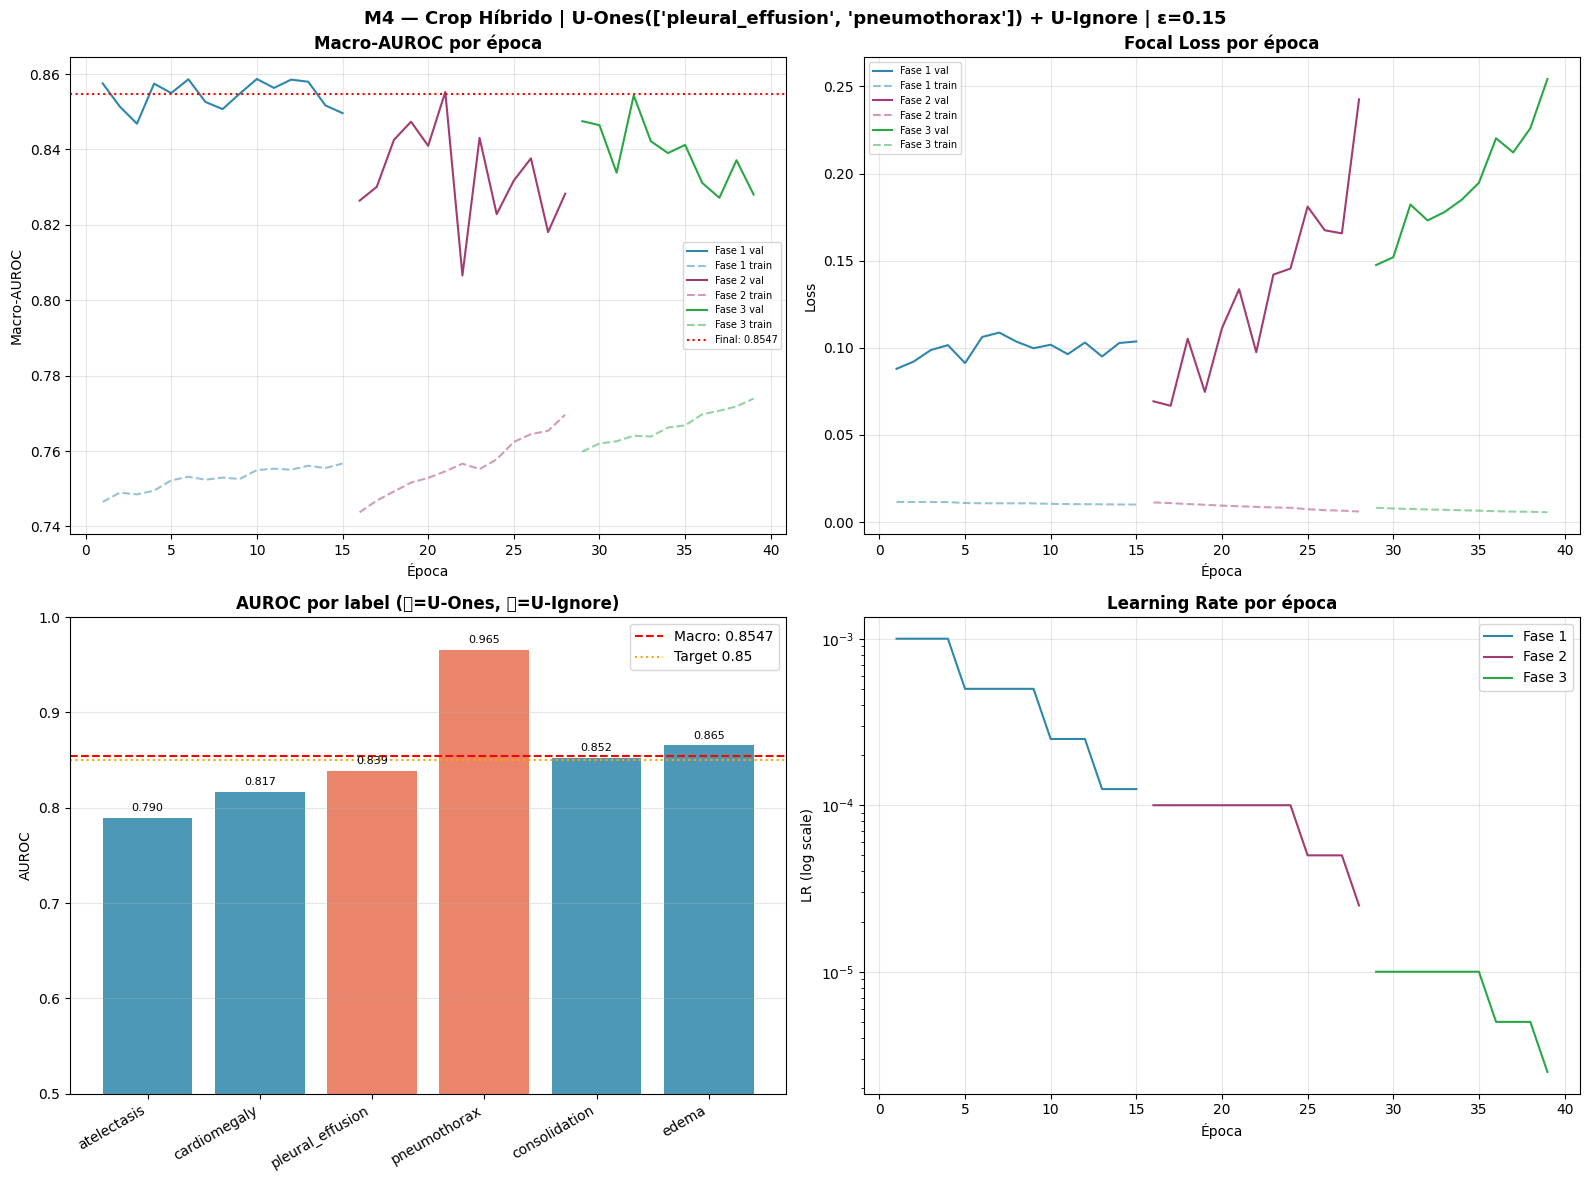

Curvas salvas.


In [16]:
def load_history(phase):
    log_path = f'{LOG_DIR}/{PREFIX}_fase{phase}_history.csv'
    if os.path.exists(log_path):
        return pd.read_csv(log_path)
    return None

hist_p1 = load_history(1)
hist_p2 = load_history(2)
hist_p3 = load_history(3)

if 'macro_auroc' not in dir() or 'per_label' not in dir():
    with open(f'{OUT_DIR}/m4_results.json') as f:
        res = json.load(f)
    macro_auroc = res['macro_auroc']
    per_label   = res['per_label_auroc']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(f'M4 — Crop Híbrido | U-Ones({UONES_LABELS}) + U-Ignore | ε={LABEL_SMOOTHING_EPSILON}',
             fontsize=13, fontweight='bold')
colors = {'Fase 1':'#2E86AB','Fase 2':'#A23B72','Fase 3':'#28A745'}

def plot_metric(ax, metric, val_metric, title, ylabel):
    offset = 0
    for fase, hist in [('Fase 1',hist_p1),('Fase 2',hist_p2),('Fase 3',hist_p3)]:
        if hist is None: continue
        epochs = range(offset+1, offset+len(hist)+1)
        ax.plot(epochs, hist[val_metric], label=f'{fase} val', color=colors[fase])
        if metric in hist.columns:
            ax.plot(epochs, hist[metric], label=f'{fase} train',
                    color=colors[fase], linestyle='--', alpha=0.5)
        offset += len(hist)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Época'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plot_metric(axes[0,0], 'macro_auroc', 'val_macro_auroc', 'Macro-AUROC por época', 'Macro-AUROC')
axes[0,0].axhline(y=macro_auroc, color='red', linestyle=':', label=f'Final: {macro_auroc:.4f}')
axes[0,0].legend(fontsize=7)

plot_metric(axes[0,1], 'loss', 'val_loss', 'Focal Loss por época', 'Loss')

ax3 = axes[1,0]
colors_bar = ['#E76F51' if l in UONES_LABELS else '#2E86AB' for l in per_label.keys()]
bars = ax3.bar(per_label.keys(), per_label.values(), color=colors_bar, alpha=0.85)
ax3.axhline(y=macro_auroc, color='red', linestyle='--', label=f'Macro: {macro_auroc:.4f}')
ax3.axhline(y=0.85, color='orange', linestyle=':', label='Target 0.85')
ax3.set_title('AUROC por label (🟠=U-Ones, 🔵=U-Ignore)', fontweight='bold')
ax3.set_ylabel('AUROC'); ax3.set_ylim(0.5, 1.0)
ax3.legend(); ax3.grid(axis='y', alpha=0.3)
plt.sca(ax3); plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, per_label.values()):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax4 = axes[1,1]
offset = 0
for fase, hist in [('Fase 1',hist_p1),('Fase 2',hist_p2),('Fase 3',hist_p3)]:
    if hist is None: continue
    col = 'lr' if 'lr' in hist.columns else ('learning_rate' if 'learning_rate' in hist.columns else None)
    if col:
        epochs = range(offset+1, offset+len(hist)+1)
        ax4.semilogy(epochs, hist[col], label=fase, color=colors[fase])
    offset += len(hist)
ax4.set_title('Learning Rate por época', fontweight='bold')
ax4.set_xlabel('Época'); ax4.set_ylabel('LR (log scale)')
ax4.legend(); ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/m4_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Curvas salvas.')

In [17]:
# ── Salva modelo final ────────────────────────────────────────────────────────
if 'best_model' not in dir():
    CKPT_P3 = f'{CKPT_DIR}/{PREFIX}_fase3_best.keras'
    best_model = tf.keras.models.load_model(CKPT_P3, custom_objects=CUSTOM_OBJECTS)
    print('Modelo carregado do checkpoint P3.')

if 'macro_auroc' not in dir():
    with open(f'{OUT_DIR}/m4_results.json') as f:
        res = json.load(f); macro_auroc = res['macro_auroc']

final_path = f'{OUT_DIR}/m4_final.keras'
best_model.save(final_path)
print(f'Modelo final salvo: {final_path}')

separador = '=' * 55
status_str = 'Atingido' if macro_auroc >= 0.85 else 'Abaixo do target'
print(f'\n{separador}')
print(f'M4 Crop Híbrido ε={LABEL_SMOOTHING_EPSILON} — RESUMO FINAL')
print(f'{separador}')
print(f'  Macro-AUROC : {macro_auroc:.4f}')
print(f'  Target      : 0.85–0.92')
print(f'  Status      : {status_str}')
print(f'  Política    : U-Ones({UONES_LABELS}) + U-Ignore({UIGNORE_LABELS})')
print(f'  LS epsilon  : {LABEL_SMOOTHING_EPSILON} (apenas U-Ones labels)')
print(f'  Modelo      : {final_path}')
print(f'{separador}')

Modelo final salvo: /content/drive/MyDrive/datasets_pi_2026/modelos/M4_CheXpert_Crop_Hybrid/m4_final.keras

M4 Crop Híbrido ε=0.15 — RESUMO FINAL
  Macro-AUROC : 0.8547
  Target      : 0.85–0.92
  Status      : Atingido
  Política    : U-Ones(['pleural_effusion', 'pneumothorax']) + U-Ignore(['atelectasis', 'cardiomegaly', 'consolidation', 'edema'])
  LS epsilon  : 0.15 (apenas U-Ones labels)
  Modelo      : /content/drive/MyDrive/datasets_pi_2026/modelos/M4_CheXpert_Crop_Hybrid/m4_final.keras


## SEÇÃO 11 — Relatório

In [18]:
!pip install -q anthropic
import anthropic

API_KEY = '<API_KEY>'
client  = anthropic.Anthropic(api_key=API_KEY)

if 'macro_auroc' not in dir() or 'per_label' not in dir():
    with open(f'{OUT_DIR}/m4_results.json') as f:
        res = json.load(f)
    macro_auroc = res['macro_auroc']
    per_label   = res['per_label_auroc']

def load_history(phase):
    log_path = f'{LOG_DIR}/{PREFIX}_fase{phase}_history.csv'
    if os.path.exists(log_path):
        df = pd.read_csv(log_path)
        col = 'lr' if 'lr' in df.columns else ('learning_rate' if 'learning_rate' in df.columns else None)
        if col and col != 'lr': df = df.rename(columns={col:'lr'})
        return df
    return None

def hist_summary(hist, phase):
    if hist is None: return f'Fase {phase}: sem dados'
    best_val = hist['val_macro_auroc'].max()
    best_ep  = hist['val_macro_auroc'].idxmax() + 1
    lr_str   = f'{float(hist["lr"].iloc[-1]):.2e}' if 'lr' in hist.columns else 'N/A'
    return (f'Fase {phase}: {len(hist)} epochs | '
            f'Melhor val_macro_auroc={best_val:.4f} (epoch {best_ep}) | LR final={lr_str}')

hist_p1 = load_history(1)
hist_p2 = load_history(2)
hist_p3 = load_history(3)

# Carrega M1, M2, M3 para trajetória completa
refs = {}
for name, path in [
    ('m1', f'{BASE_DRIVE}/datasets_pi_2026/modelos/M1_NIH/m1_results.json'),
    ('m2', f'{BASE_DRIVE}/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore/m2_crop_results.json'),
    ('m3', f'{BASE_DRIVE}/datasets_pi_2026/modelos/M3_CheXpert_Crop_UOnes/m3_results.json'),
]:
    try:
        with open(path) as f: refs[name] = json.load(f)
    except Exception: refs[name] = None

# Variáveis auxiliares
label_lines = []
for lbl in LABELS:
    m1v  = refs['m1']['per_label_auroc'].get(lbl, 0) if refs['m1'] else 0
    m2v  = refs['m2']['per_label_auroc'].get(lbl, 0) if refs['m2'] else 0
    m3v  = refs['m3']['per_label_auroc'].get(lbl, 0) if refs['m3'] else 0
    m4v  = per_label.get(lbl, 0)
    pol  = 'U-Ones' if lbl in UONES_LABELS else 'U-Ignore'
    label_lines.append(
        f'  {lbl:<22} [{pol:<8}]: '
        f'M1={m1v:.4f} | M2={m2v:.4f} | M3={m3v:.4f} | M4={m4v:.4f} | '
        f'ΔM2→M4={m4v-m2v:+.4f} | ΔM3→M4={m4v-m3v:+.4f}'
    )

label_table  = '\n'.join(label_lines)
separador    = '─' * 75
m1_str       = f'{refs["m1"]["macro_auroc"]:.4f}' if refs['m1'] else 'N/A'
m2_str       = f'{refs["m2"]["macro_auroc"]:.4f}' if refs['m2'] else 'N/A'
m3_str       = f'{refs["m3"]["macro_auroc"]:.4f}' if refs['m3'] else 'N/A'
delta_m2_m4  = f'{macro_auroc - refs["m2"]["macro_auroc"]:+.4f}' if refs['m2'] else 'N/A'
delta_m3_m4  = f'{macro_auroc - refs["m3"]["macro_auroc"]:+.4f}' if refs['m3'] else 'N/A'
status_str   = 'Atingido' if macro_auroc >= 0.85 else 'Abaixo do target'
ls_target    = 1.0 - LABEL_SMOOTHING_EPSILON

context = f"""
MODELO: M4 — Xception 512×512 | Center Crop | Política Híbrida U-Ignore + U-Ones Seletivo
OBJETIVO: Testar se U-Ones aplicado APENAS nos labels com evidência favorável (pleural_effusion, pneumothorax)
          supera M2 U-Ignore puro sem o colapso de especificidade observado no M3 U-Ones irrestrito

DECISÃO DE DESIGN (baseada em M3):
  M3 U-Ones irrestrito causou colapso de especificidade (0.21 macro) e queda de Macro-AUROC (-0.0309)
  Edema e cardiomegaly: colapso total de especificidade → U-Ignore no M4
  Pneumothorax (+0.0056) e Pleural Effusion (-0.0092, mais tolerante): → U-Ones com ε={LABEL_SMOOTHING_EPSILON}

POLÍTICA POR LABEL:
  U-Ones  (ε={LABEL_SMOOTHING_EPSILON}, target 1→{ls_target}): {UONES_LABELS}
  U-Ignore (máscara, como M2)           : {UIGNORE_LABELS}
  Base                                   : m2_crop_final.keras

ESTRATÉGIA DE TREINO:
  {hist_summary(hist_p1, 1)}
  {hist_summary(hist_p2, 2)}
  {hist_summary(hist_p3, 3)}

TRAJETÓRIA COMPLETA DO ABLATION — M1 | M2 | M3 | M4:
{label_table}
  {separador}
  M1  Macro-AUROC (NIH baseline)          : {m1_str}
  M2  Macro-AUROC (Crop + U-Ignore puro)  : {m2_str}
  M3  Macro-AUROC (Crop + U-Ones irrest.) : {m3_str}
  M4  Macro-AUROC (Crop + Híbrido)        : {macro_auroc:.4f}
  ΔM2→M4                                  : {delta_m2_m4}
  ΔM3→M4                                  : {delta_m3_m4}
  Target                                   : 0.85–0.92
  Status                                   : {status_str}
"""

prompt = f"""Você é um pesquisador sênior em visão computacional médica.

Abaixo estão os resultados do modelo M4 — política híbrida de labels incertos, etapa final do ablation study de classificação multi-label de CXR com Xception 512×512 no CheXpert.

{context}

Produza um relatório técnico estruturado cobrindo:

1. **Resumo executivo**: M4 superou M2? A política híbrida funcionou? Qual o veredicto final do ablation?
2. **Análise por label — M4 vs M2**: os labels U-Ones (pleural_effusion, pneumothorax) melhoraram conforme esperado? Os labels U-Ignore foram preservados?
3. **Comparação M4 vs M3**: a política seletiva corrigiu o colapso de especificidade observado no M3?
4. **Trajetória M1→M2→M3→M4**: o que cada etapa contribuiu para o entendimento do problema?
5. **Papel do ε={LABEL_SMOOTHING_EPSILON}**: foi adequado para os labels U-Ones?
6. **Comportamento do treino**: overfitting, fases, resposta ao scheduler vs M2 e M3
7. **Modelo recomendado para publicação**: M2 ou M4? Justificativa técnica
8. **Limitações e próximos passos**: o que o ablation não pôde responder?

Seja direto, técnico e cite os números. Responda em português brasileiro."""

print('Enviando para Claude API...')
t0 = time.time()
message = client.messages.create(
    model='claude-sonnet-4-6', max_tokens=8192,
    messages=[{'role':'user','content':prompt}]
)
relatorio = message.content[0].text
elapsed   = time.time() - t0
print(f'Resposta em {elapsed:.1f}s | {message.usage.input_tokens} in | {message.usage.output_tokens} out')

print('\n' + '='*65)
print('RELATÓRIO M4 — Claude Sonnet')
print('='*65)
print(relatorio)

report_path = f'{OUT_DIR}/m4_relatorio_claude.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(context + '\n\n' + '='*65 + '\nRELATÓRIO CLAUDE\n' + '='*65 + '\n\n' + relatorio)
print(f'\nRelatório salvo: {report_path}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 40.8 MB/s eta 0:00:00
Enviando para Claude API...
Resposta em 113.3s | 1552 in | 6051 out

RELATÓRIO M4 — Claude Sonnet
# Relatório Técnico — Ablation Study Final: Política de Labels Incertos em Classificação Multi-Label de CXR

**Modelo:** M4 — Xception 512×512 | Center Crop | Política Híbrida U-Ignore + U-Ones Seletivo
**Dataset:** CheXpert | **Arquitetura:** Xception | **Resolução:** 512×512
**Data de análise:** Etapa final do ablation study de 4 modelos

---

## 1. Resumo Executivo

**M4 não superou M2.** A política híbrida atingiu Macro-AUROC de **0.8547**, contra **0.8710** de M2 — um deficit de **−0.0163** que é clinicamente e estatisticamente relevante neste contexto. Contudo, M4 cumpriu seu objetivo imediato ao superar M3 (**0.8403**) em **+0.0144**, demonstrando que a seletividade na aplicação de U-Ones é condição necessária — mas não suficiente — para superar o baseline de U-Ignore puro.

**A política híbrida funcion